In [12]:
import pandas as pd
import numpy as np
import os
from dotenv import load_dotenv
import pymysql
import pandas as pd

load_dotenv()  # .env 파일 읽어서 환경변수로 등록

conn = pymysql.connect(
    host=os.getenv("DB_HOST"),
    port=int(os.getenv("DB_PORT")),
    user=os.getenv("DB_USER"),
    password=os.getenv("DB_PASSWORD"),
    database=os.getenv("DB_NAME"),
    charset="utf8mb4"
)




query_main = """
SELECT
    t.sido, t.sigungu,
    COUNT(*) AS toilet_count,
    SUM(t.total_seats) AS total_seats,
    p.total_pop
FROM tb_toilet t
JOIN tb_population p ON t.sido = p.sido AND t.sigungu = p.sigungu
GROUP BY t.sido, t.sigungu, p.total_pop
"""

df = pd.read_sql(query_main, conn)
print(df.shape)
df.head()

C:\Users\CY\AppData\Local\Temp\ipykernel_26464\1940760838.py:33: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df = pd.read_sql(query_main, conn)


(251, 5)


,sido,sigungu,toilet_count,total_seats,total_pop
0,강원특별자치도,강릉시,379,4976.0,205666
1,강원특별자치도,고성군,241,2023.0,27204
2,강원특별자치도,동해시,204,2328.0,85589
3,강원특별자치도,삼척시,176,1927.0,60294
4,강원특별자치도,속초시,233,2577.0,78893


In [ ]:
# 1
query_main = """
SELECT
    t.sido, t.sigungu,
    COUNT(*) AS toilet_count,
    SUM(t.total_seats) AS total_seats,
    p.total_pop,
    ROUND(SUM(t.total_seats) * 10000.0 / p.total_pop, 2) AS seats_per_10k
FROM tb_toilet t
JOIN tb_population p ON t.sido = p.sido AND t.sigungu = p.sigungu
GROUP BY t.sido, t.sigungu, p.total_pop
HAVING COUNT(*) >= 10
ORDER BY seats_per_10k DESC
"""

df_main = pd.read_sql(query_main, conn)

print("전국 평균:", df_main['seats_per_10k'].mean())
print("표준편차:", df_main['seats_per_10k'].std())
cv = df_main['seats_per_10k'].std() / df_main['seats_per_10k'].mean()
print(f"변동계수(CV): {cv:.2f}")

print(df_main.nlargest(5, 'seats_per_10k')[['sido','sigungu','toilet_count','total_pop','seats_per_10k']])
print(df_main.nsmallest(5, 'seats_per_10k')[['sido','sigungu','toilet_count','total_pop','seats_per_10k']])

C:\Users\CY\AppData\Local\Temp\ipykernel_26464\2340943457.py:15: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df_main = pd.read_sql(query_main, conn)


전국 평균: 219.925685483871
표준편차: 204.16802890724173
변동계수(CV): 0.93
      sido sigungu  toilet_count  total_pop  seats_per_10k
0     충청북도     단양군           335      26628        1022.23
1    대구광역시     군위군           258      22622         977.81
2  강원특별자치도     화천군           150      22579         900.39
3     충청남도     금산군           366      48939         884.16
4  강원특별자치도     태백시           334      36811         880.17
      sido    sigungu  toilet_count  total_pop  seats_per_10k
247   충청북도        진천군            22      85569           3.97
246   충청북도    청주시 서원구            41     187779          12.46
245  대구광역시         동구            64     338476          19.56
244   경상남도  창원시 마산회원구            48     174175          21.82
243  부산광역시        금정구            57     205672          22.95


In [19]:
print(df_main.columns.tolist())

['sido', 'sigungu', 'toilet_count', 'total_seats', 'total_pop', 'seats_per_10k']


In [20]:
print("=== 밀도 상위 5개 지역 ===")
print(df_main.nlargest(5, 'seats_per_10k')[['sido','sigungu','toilet_count','total_pop','seats_per_10k']])

print("\n=== 밀도 하위 5개 지역 ===")
print(df_main.nsmallest(5, 'seats_per_10k')[['sido','sigungu','toilet_count','total_pop','seats_per_10k']])

=== 밀도 상위 5개 지역 ===
      sido sigungu  toilet_count  total_pop  seats_per_10k
0     충청북도     단양군           335      26628        1022.23
1    대구광역시     군위군           258      22622         977.81
2  강원특별자치도     화천군           150      22579         900.39
3     충청남도     금산군           366      48939         884.16
4  강원특별자치도     태백시           334      36811         880.17

=== 밀도 하위 5개 지역 ===
      sido    sigungu  toilet_count  total_pop  seats_per_10k
247   충청북도        진천군            22      85569           3.97
246   충청북도    청주시 서원구            41     187779          12.46
245  대구광역시         동구            64     338476          19.56
244   경상남도  창원시 마산회원구            48     174175          21.82
243  부산광역시        금정구            57     205672          22.95


In [ ]:
import pandas as pd
import numpy as np


# 1. SQL 쿼리 결과 가져오기

query_seats = """
SELECT
    t.sido, t.sigungu,
    COUNT(*) AS toilet_count,
    SUM(t.total_seats) AS total_seats,
    ROUND(SUM(t.total_seats) * 1.0 / COUNT(*), 2) AS avg_seats_per_toilet
FROM tb_toilet t
GROUP BY t.sido, t.sigungu
HAVING COUNT(*) >= 10
ORDER BY avg_seats_per_toilet DESC
"""

df_seats = pd.read_sql(query_seats, conn)
print(df_seats.shape)
df_seats.head()


# 2. 정규화 지표 및 분포 확인 (변동계수 CV)

mean_val = df_seats['avg_seats_per_toilet'].mean()
std_val = df_seats['avg_seats_per_toilet'].std()
cv = std_val / mean_val

print(f"전국 평균: {mean_val:.2f}개/화장실")
print(f"표준편차: {std_val:.2f}")
print(f"최댓값: {df_seats['avg_seats_per_toilet'].max()} vs 최솟값: {df_seats['avg_seats_per_toilet'].min()}")
print(f"변동계수(CV): {cv:.2f}")


# 3. z-score 표준화 + np.where로 이상치 분류

df_seats['seats_z'] = (df_seats['avg_seats_per_toilet'] - mean_val) / std_val

df_seats['tier'] = np.where(
    df_seats['seats_z'] >= 1, '상위 이상치(대형화장실 밀집)',
    np.where(df_seats['seats_z'] <= -1, '하위 취약지역(소형화장실 위주)', '평균 범위')
)

print(df_seats['tier'].value_counts())


# 4. 상/하위 지역 확인

print("\n=== 화장실 1개당 변기 수 상위 5개 지역 ===")
print(df_seats.nlargest(5, 'avg_seats_per_toilet')[['sido','sigungu','toilet_count','total_seats','avg_seats_per_toilet']])

print("\n=== 화장실 1개당 변기 수 하위 5개 지역 ===")
print(df_seats.nsmallest(5, 'avg_seats_per_toilet')[['sido','sigungu','toilet_count','total_seats','avg_seats_per_toilet']])

ompare = df_seats.merge(df_main[['sido','sigungu','seats_per_10k']], on=['sido','sigungu'], how='inner')
corr_check = compare['avg_seats_per_toilet'].corr(compare['seats_per_10k'])
print(f"\n[참고] avg_seats_per_toilet vs seats_per_10k 상관계수: {corr_check:.3f}")
print("→ 이 값이 낮을수록, 가설 1과 가설 2가 서로 다른 현상을 측정하고 있다는 근거가 됩니다.")


(248, 5)
전국 평균: 12.49개/화장실
표준편차: 5.68
최댓값: 46.66 vs 최솟값: 1.55
변동계수(CV): 0.45
tier
평균 범위                205
상위 이상치(대형화장실 밀집)      30
하위 취약지역(소형화장실 위주)     13
Name: count, dtype: int64

=== 화장실 1개당 변기 수 상위 5개 지역 ===
      sido sigungu  toilet_count  total_seats  avg_seats_per_toilet
0    인천광역시     계양구           346      16143.0                 46.66
1      경기도     김포시           313      13808.0                 44.12
2      경기도     과천시            89       3380.0                 37.98
3  전북특별자치도     익산시           289       9499.0                 32.87
4  강원특별자치도     평창군           128       3310.0                 25.86

=== 화장실 1개당 변기 수 하위 5개 지역 ===
        sido  sigungu  toilet_count  total_seats  avg_seats_per_toilet
247     충청북도      진천군            22         34.0                  1.55
246  강원특별자치도      인제군            32        100.0                  3.13
245  전북특별자치도      순창군           127        618.0                  4.87
244     충청북도  청주시 서원구            41        234.0               

C:\Users\CY\AppData\Local\Temp\ipykernel_26464\656279383.py:19: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df_seats = pd.read_sql(query_seats, conn)


In [21]:
#3번 상관계수 계산
query_disabled = """
SELECT
    t.sido, t.sigungu,
    COUNT(*) AS toilet_count,
    ROUND(SUM(t.disabled_seats) * 100.0 / SUM(t.total_seats), 2) AS disabled_seats_ratio_pct,
    ROUND(p.elderly_pop * 100.0 / p.total_pop, 1) AS elderly_ratio_pct
FROM tb_toilet t
JOIN tb_population p ON t.sido = p.sido AND t.sigungu = p.sigungu
GROUP BY t.sido, t.sigungu, p.elderly_pop, p.total_pop
HAVING COUNT(*) >= 10
ORDER BY elderly_ratio_pct DESC
"""

df_disabled = pd.read_sql(query_disabled, conn)
print(df_disabled.shape)
df_disabled.head()

# 상관계수 계산
corr = df_disabled['elderly_ratio_pct'].corr(df_disabled['disabled_seats_ratio_pct'])
print(f"고령인구 비율 vs 장애인용 변기 비율 상관계수: {corr:.3f}")

# z-score, tier - 표준화 및 이상치 판별
df_disabled['ratio_z'] = (
    (df_disabled['disabled_seats_ratio_pct'] - df_disabled['disabled_seats_ratio_pct'].mean())
    / df_disabled['disabled_seats_ratio_pct'].std()
)

df_disabled['tier'] = np.where(
    df_disabled['ratio_z'] >= 1, '상위 이상치',
    np.where(df_disabled['ratio_z'] <= -1, '하위 취약지역', '평균 범위')
)
# 고령인구 비율 상위 10곳- 장애인용 변기 비율과 z-score, tier 출력 
print(df_disabled.sort_values('elderly_ratio_pct', ascending=False).head(10))

C:\Users\CY\AppData\Local\Temp\ipykernel_26464\891292259.py:15: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df_disabled = pd.read_sql(query_disabled, conn)


(248, 5)
고령인구 비율 vs 장애인용 변기 비율 상관계수: -0.123
    sido sigungu  toilet_count  disabled_seats_ratio_pct  elderly_ratio_pct  \
0   경상북도     의성군           169                     13.99               50.1   
1  대구광역시     군위군           258                      7.50               49.9   
2   경상남도     합천군           240                     16.34               48.7   
3   전라남도     고흥군           293                      9.06               48.2   
4   경상북도     청도군           201                     30.47               47.6   
5   경상북도     봉화군           273                      9.72               46.7   
6   경상북도     영덕군           196                      5.96               45.9   
7   경상남도     의령군           110                     16.42               45.7   
8   경상북도     청송군           195                      4.31               45.1   
9   전라남도     보성군           245                     12.08               44.9   

    ratio_z    tier  
0  0.140880   평균 범위  
1 -0.594460   평균 범위  
2  0.407144   평균 범위 

In [ ]:
# 4번

query_diaper = """
SELECT
    t.sido, t.sigungu,
    COUNT(*) AS toilet_count,
    ROUND(AVG(t.has_diaper_table) * 100, 1) AS diaper_rate_pct,
    ROUND(p.child_pop * 100.0 / p.total_pop, 1) AS child_ratio_pct
FROM tb_toilet t
JOIN tb_population p ON t.sido = p.sido AND t.sigungu = p.sigungu
GROUP BY t.sido, t.sigungu, p.child_pop, p.total_pop
HAVING COUNT(*) >= 10
ORDER BY child_ratio_pct DESC
"""

df_diaper = pd.read_sql(query_diaper, conn)
print(df_diaper.shape)
df_diaper.head()

corr = df_diaper['child_ratio_pct'].corr(df_diaper['diaper_rate_pct'])
print(f"영유아 비율 vs 기저귀교환대 설치율 상관계수: {corr:.3f}")

C:\Users\CY\AppData\Local\Temp\ipykernel_26464\2222237219.py:14: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df_diaper = pd.read_sql(query_diaper, conn)


(248, 5)
영유아 비율 vs 기저귀교환대 설치율 상관계수: 0.226


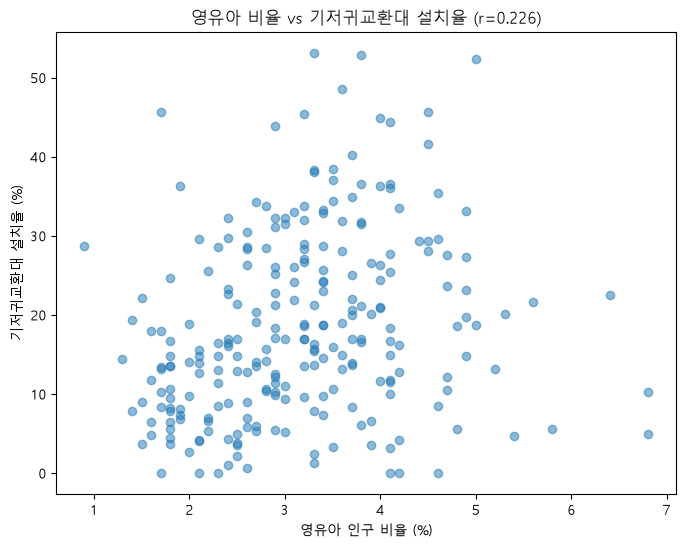

In [7]:
import matplotlib.pyplot as plt
import matplotlib

# Windows 환경 (맑은 고딕 사용)
plt.rcParams['font.family'] = 'Malgun Gothic'
plt.rcParams['axes.unicode_minus'] = False  # 마이너스 기호 깨짐 방지

plt.figure(figsize=(8,6))
plt.scatter(df_diaper['child_ratio_pct'], df_diaper['diaper_rate_pct'], alpha=0.5)
plt.xlabel('영유아 인구 비율 (%)')
plt.ylabel('기저귀교환대 설치율 (%)')
plt.title(f'영유아 비율 vs 기저귀교환대 설치율 (r={corr:.3f})')
plt.show()

In [8]:
# 영유아 비율은 높은데(상위권) 설치율은 낮은(하위권) 지역
high_child_low_diaper = df_diaper[
    (df_diaper['child_ratio_pct'] >= 5) & (df_diaper['diaper_rate_pct'] <= 20)
].sort_values('child_ratio_pct', ascending=False)

print("영유아 비율 높은데 설치율 낮은 지역:")
print(high_child_low_diaper[['sido','sigungu','child_ratio_pct','diaper_rate_pct']])

영유아 비율 높은데 설치율 낮은 지역:
    sido  sigungu  child_ratio_pct  diaper_rate_pct
0    경기도  화성시 동탄구              6.8              5.0
1  부산광역시      강서구              6.8             10.2
3    경기도  화성시 효행구              5.8              5.6
5    경기도  화성시 병점구              5.4              4.7
7   충청북도  청주시 흥덕구              5.2             13.2
8  대전광역시      유성구              5.0             18.7
